## AWS fraud-detection architecture with Sagemaker

Transaction → Lambda → Feature Engineering → SageMaker Model → Fraud Score → Decision

Payment / Transaction

        ↓
        
API Gateway

        ↓

AWS Lambda

        ↓

Feature Extraction

        ↓

SageMaker Endpoint

        ↓

Fraud Probability

        ↓

Decision Engine

   ┌────┼────┐
   
   ↓    ↓    ↓

ALLOW REVIEW BLOCK

`{
  "customer_id": "C123",
  "amount": 85000,
  "merchant_id": "M456",
  "location": "Bangalore",
  "device_id": "D789",
  "timestamp": "2026-08-21T09:30:00"
}`

Example features:

transaction_amount,transaction_frequency_1h,transaction_frequency_24h,average_transaction_amount,amount_deviation_from_customer_average,merchant_risk_score,device_risk_score,ip_risk_score,location_change_distance,time_since_last_transaction,failed_transaction_count,account_age,previous_chargebacks


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt	
from imblearn.over_sampling import SMOTE
from geopy.distance import geodesic
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder  
import xgboost as xgb  

In [74]:
# df = pd.read_parquet("s3://fraud-data/transactions.parquet")
transactions = pd.read_csv("bank_transactions_data_2.csv")

In [75]:
transactions.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,IsFraud
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08,No
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35,Yes
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04,Yes
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06,Yes
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39,No


In [76]:
transactions.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [77]:
df = transactions.sort_values(by="TransactionDate").copy()
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,IsFraud
1062,TX001063,AC00456,68.10,2023-01-02 16:00:06,Debit,Milwaukee,D000235,94.227.164.192,M089,ATM,20,Student,47,1,1382.80,2024-11-04 08:10:15,Yes
1368,TX001369,AC00316,487.16,2023-01-02 16:01:14,Credit,Los Angeles,D000361,156.96.135.18,M077,Branch,28,Student,84,1,321.21,2024-11-04 08:12:22,Yes
1622,TX001623,AC00087,154.21,2023-01-02 16:01:26,Debit,Miami,D000549,190.251.45.32,M083,Online,46,Engineer,75,1,8045.77,2024-11-04 08:10:33,No
982,TX000983,AC00281,453.49,2023-01-02 16:06:29,Debit,Seattle,D000471,40.226.196.34,M088,Branch,66,Doctor,147,1,6366.43,2024-11-04 08:08:56,Yes
876,TX000877,AC00304,204.06,2023-01-02 16:07:17,Debit,Washington,D000685,150.231.20.169,M069,Online,77,Retired,159,1,4351.83,2024-11-04 08:07:22,Yes


In [78]:
# 1. CRITICAL FIX: Explicitly convert TransactionDate to datetime objects
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

# 2. Sort the data chronologically per account
df = df.sort_values(by=['AccountID', 'TransactionDate']).copy()

# 3. Create a temporary time index column and set it as the index
df['temp_time_index'] = df['TransactionDate']
df = df.set_index('temp_time_index')

# 4. Calculate your rolling windows (this will now work correctly!)
df['tx_count_10m'] = df.groupby('AccountID')['TransactionAmount'].rolling('10min').count().reset_index(0, drop=True)
df['tx_count_1h'] = df.groupby('AccountID')['TransactionAmount'].rolling('1h').count().reset_index(0, drop=True)
df['tx_count_24h'] = df.groupby('AccountID')['TransactionAmount'].rolling('24h').count().reset_index(0, drop=True)

# 5. Drop the temporary index and revert back to a standard numeric index
df = df.reset_index(drop=True)

In [79]:
# 1. Calculate the historical average transaction amount for each user
# using expanding window so it only looks at past data (no future leakage)
df['user_historical_mean'] = df.groupby('AccountID')['TransactionAmount'].expanding().mean().reset_index(0, drop=True)

# 2. Create a ratio metric: Current Amount / Historical Average
df['amount_to_mean_ratio'] = df['TransactionAmount'] / (df['user_historical_mean'] + 1e-5) # 1e-5 prevents division by zero

# 3. Flag transactions that are 5x or higher than normal
df['is_amount_5x_higher'] = (df['amount_to_mean_ratio'] >= 5.0).astype(int)

In [80]:
# 1. Get the previous IP and previous time
df['prev_IP'] = df.groupby('AccountID')['IP Address'].shift(1)
df['prev_time'] = df.groupby('AccountID')['TransactionDate'].shift(1)

# 2. Check if the IP changed from the last transaction
df['ip_changed'] = (df['IP Address'] != df['prev_IP']).astype(int)

# 3. Calculate time elapsed since the last transaction (in minutes)
df['minutes_since_last_tx'] = (df['TransactionDate'] - df['prev_time']).dt.total_seconds() / 60.0

# 4. Feature: Fast IP Switch
df['is_fast_ip_switch'] = np.where((df['ip_changed'] == 1) & (df['minutes_since_last_tx'] < 30), 1, 0)

# 5. FIXED: Track cumulative unique text values by finding first-time appearances
# Step A: Identify every row where a user hits a specific IP address for the VERY FIRST time
is_new_ip_for_user = ~df.duplicated(subset=['AccountID', 'IP Address'])

# Step B: Convert those True/False booleans to integers (1s and 0s) so they are numeric
df['is_new_ip_numeric'] = is_new_ip_for_user.astype(int)

# Step C: Use a numeric cumulative sum (.cumsum()) per account to calculate unique counts over time
df['unique_ip_count'] = df.groupby('AccountID')['is_new_ip_numeric'].cumsum()

# Step D: Drop the helper column to keep your dataframe clean
df = df.drop(columns=['is_new_ip_numeric'])

In [81]:
# 1. FIX THE NULL VALUES: Replace NaNs in 'minutes_since_last_tx'
# For a first transaction, we set a high default number (e.g., 999999 minutes) 
# so the model knows it was not a rapid "fast IP switch".
df['minutes_since_last_tx'] = df['minutes_since_last_tx'].fillna(999999.0)

In [82]:
columns_to_drop = [
    'TransactionDate',     # DateTime objects break SMOTE
    'prev_time',           # DateTime objects break SMOTE
    'IP Address',          # Strings/Objects break SMOTE
    'prev_IP',             # Strings/Objects break SMOTE
    'TransactionID',       # Drop anyway (prevents model memorization/overfitting)
    'DeviceID'             # Drop anyway (prevents model memorization/overfitting)
]
df = df.drop(columns=columns_to_drop)

In [83]:
features = df.columns.tolist()
features.remove("IsFraud")
features

['AccountID',
 'TransactionAmount',
 'TransactionType',
 'Location',
 'MerchantID',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance',
 'PreviousTransactionDate',
 'tx_count_10m',
 'tx_count_1h',
 'tx_count_24h',
 'user_historical_mean',
 'amount_to_mean_ratio',
 'is_amount_5x_higher',
 'ip_changed',
 'minutes_since_last_tx',
 'is_fast_ip_switch',
 'unique_ip_count']

In [84]:
# Encode categorical columns  
cat_cols = df.select_dtypes(include=['object', 'str']).columns
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(
        df[col].astype(str)
    )

In [85]:
df.head()

,AccountID,TransactionAmount,TransactionType,Location,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,...,tx_count_10m,tx_count_1h,tx_count_24h,user_historical_mean,amount_to_mean_ratio,is_amount_5x_higher,ip_changed,minutes_since_last_tx,is_fast_ip_switch,unique_ip_count
0,0,47.79,1,10,33,1,25,3,37,1,...,1.0,1.0,1.0,47.790000,1.000000,0,1,999999.000000,0,1
1,0,212.97,1,1,2,2,59,1,178,1,...,1.0,1.0,1.0,130.380000,1.633456,0,1,86396.233333,0,2
2,1,476.99,1,36,21,2,23,3,187,1,...,1.0,1.0,1.0,476.990000,1.000000,0,1,999999.000000,0,1
3,1,59.32,1,20,39,1,71,2,38,1,...,1.0,1.0,1.0,268.155000,0.221215,0,1,70596.433333,0,2
4,1,12.62,1,12,67,1,33,0,61,1,...,1.0,1.0,1.0,182.976667,0.068971,0,1,95038.766667,0,3


In [86]:
X = df[features]
y = df["IsFraud"]

In [87]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AccountID                2512 non-null   int64  
 1   TransactionAmount        2512 non-null   float64
 2   TransactionType          2512 non-null   int64  
 3   Location                 2512 non-null   int64  
 4   MerchantID               2512 non-null   int64  
 5   Channel                  2512 non-null   int64  
 6   CustomerAge              2512 non-null   int64  
 7   CustomerOccupation       2512 non-null   int64  
 8   TransactionDuration      2512 non-null   int64  
 9   LoginAttempts            2512 non-null   int64  
 10  AccountBalance           2512 non-null   float64
 11  PreviousTransactionDate  2512 non-null   int64  
 12  tx_count_10m             2512 non-null   float64
 13  tx_count_1h              2512 non-null   float64
 14  tx_count_24h             2512 non-n

In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [89]:
# 2. Initialize and apply SMOTE only to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [91]:
model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc"
)

model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [92]:
probabilities = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, probabilities)

print("ROC-AUC:", auc)

ROC-AUC: 0.5369649805447472


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

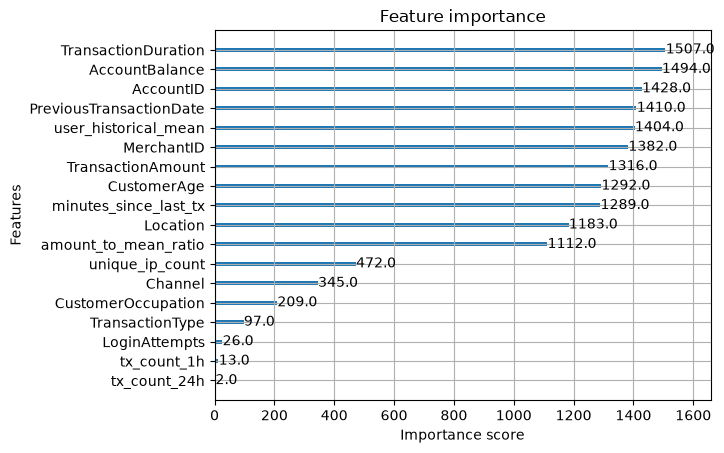

In [93]:
# ploting and testing
xgb.plot_importance(model)

In [ ]:
### we can improve the prediction higher